
Evaluating Node: A

Option: A -> ['B']

Evaluating Node: B

Option: B -> ['D', 'E']
Cost of ['D', 'E'] = 5

Option: B -> ['F', 'G']
Cost of ['F', 'G'] = 6

Best choice for B: ['D', 'E']
Best cost for B: 5
Cost of ['B'] = 7

Option: A -> ['C']

Evaluating Node: C

Option: C -> ['H', 'I']
Cost of ['H', 'I'] = 4

Option: C -> ['J', 'K']
Cost of ['J', 'K'] = 2

Best choice for C: ['J', 'K']
Best cost for C: 2
Cost of ['C'] = 6

Best choice for A: ['C']
Best cost for A: 6


          AO* RESULT
Optimal Cost: 6

Optimal Solution:
A -> C -> (J AND K)

Solution Edges:
C -> J
C -> K
A -> C


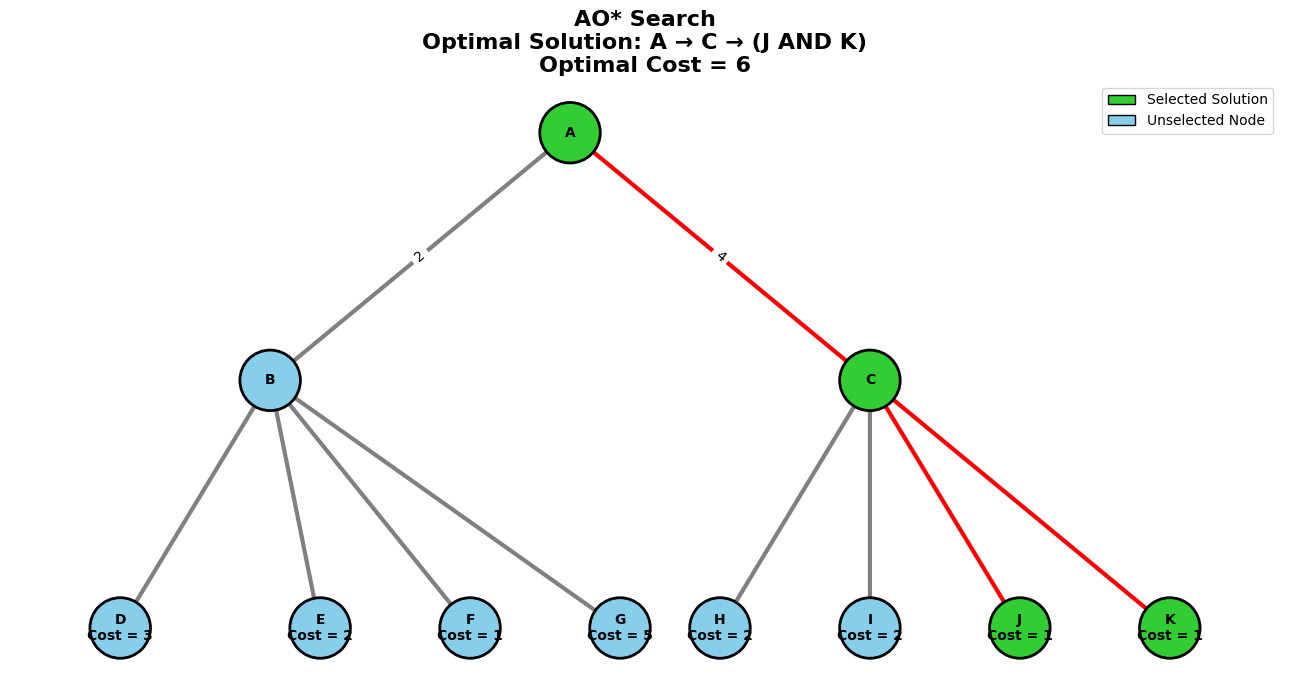

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# AO* SEARCH USING AND-OR GRAPH
# ============================================================

# Each node contains multiple alternatives.
#
# OR:
#   Choose ONE alternative with minimum cost.
#
# AND:
#   ALL children inside the selected alternative must be solved.


graph = {

    # A is an OR node
    'A': [
        (['B'], 2),
        (['C'], 4)
    ],

    # B is an OR node
    # Each alternative is an AND group
    'B': [
        (['D', 'E'], 0),
        (['F', 'G'], 0)
    ],

    # C is an OR node
    # Each alternative is an AND group
    'C': [
        (['H', 'I'], 0),
        (['J', 'K'], 0)
    ],

    # Terminal nodes
    'D': [],
    'E': [],
    'F': [],
    'G': [],
    'H': [],
    'I': [],
    'J': [],
    'K': []
}


# ============================================================
# COST / HEURISTIC VALUES
# ============================================================

heuristic = {
    'D': 3,
    'E': 2,
    'F': 1,
    'G': 5,
    'H': 2,
    'I': 2,
    'J': 1,
    'K': 1
}


# ============================================================
# AO* SEARCH
# ============================================================

def ao_star(node):

    # --------------------------------------------------------
    # Terminal node
    # --------------------------------------------------------
    if not graph[node]:

        return heuristic[node], []

    print("\n================================")
    print("Evaluating Node:", node)
    print("================================")

    best_cost = float('inf')
    best_children = None
    best_edges = []

    # --------------------------------------------------------
    # Evaluate every OR alternative
    # --------------------------------------------------------
    for children, edge_cost in graph[node]:

        total_cost = edge_cost
        current_edges = []

        print(
            f"\nOption: {node} -> {children}"
        )

        # ----------------------------------------------------
        # AND operation
        # All children must be solved
        # ----------------------------------------------------
        for child in children:

            child_cost, child_edges = ao_star(child)

            total_cost += child_cost

            current_edges.extend(child_edges)

        # Add current node -> child edges
        for child in children:

            current_edges.append(
                (node, child)
            )

        print(
            f"Cost of {children} = {total_cost}"
        )

        # ----------------------------------------------------
        # Choose minimum-cost OR alternative
        # ----------------------------------------------------
        if total_cost < best_cost:

            best_cost = total_cost
            best_children = children
            best_edges = current_edges

    print(
        f"\nBest choice for {node}: "
        f"{best_children}"
    )

    print(
        f"Best cost for {node}: "
        f"{best_cost}"
    )

    return best_cost, best_edges


# ============================================================
# RUN AO*
# ============================================================

start = 'A'

optimal_cost, solution_edges = ao_star(start)


# ============================================================
# GET ONLY SOLUTION NODES
# ============================================================

solution_nodes = set()

for u, v in solution_edges:

    solution_nodes.add(u)
    solution_nodes.add(v)


# ============================================================
# REMOVE DUPLICATE EDGES
# ============================================================

solution_edges = list(
    dict.fromkeys(solution_edges)
)


# ============================================================
# PRINT FINAL RESULT
# ============================================================

print("\n")
print("================================")
print("          AO* RESULT")
print("================================")

print(
    "Optimal Cost:",
    optimal_cost
)

print(
    "\nOptimal Solution:"
)

print(
    "A -> C -> (J AND K)"
)

print(
    "\nSolution Edges:"
)

for u, v in solution_edges:

    print(
        f"{u} -> {v}"
    )


# ============================================================
# CREATE NETWORKX GRAPH
# ============================================================

G = nx.DiGraph()

for node in graph:

    G.add_node(node)

    for children, cost in graph[node]:

        for child in children:

            G.add_edge(
                node,
                child
            )


# ============================================================
# NODE POSITIONS
# ============================================================

pos = {

    'A': (0, 4),

    'B': (-3, 2),
    'C': (3, 2),

    'D': (-4.5, 0),
    'E': (-2.5, 0),

    'F': (-1, 0),
    'G': (0.5, 0),

    'H': (1.5, 0),
    'I': (3, 0),

    'J': (4.5, 0),
    'K': (6, 0)
}


# ============================================================
# NODE COLORS
# ============================================================

node_colors = []

for node in G.nodes():

    if node in solution_nodes:

        node_colors.append("limegreen")

    else:

        node_colors.append("skyblue")


# ============================================================
# EDGE COLORS
# ============================================================

edge_colors = []

for edge in G.edges():

    if edge in solution_edges:

        edge_colors.append("red")

    else:

        edge_colors.append("gray")


# ============================================================
# NODE LABELS
# ============================================================

labels = {}

for node in G.nodes():

    if node in heuristic:

        labels[node] = (
            f"{node}\n"
            f"Cost = {heuristic[node]}"
        )

    else:

        labels[node] = node


# ============================================================
# DRAW GRAPH
# ============================================================

plt.figure(figsize=(13, 7))


# Draw edges
nx.draw_networkx_edges(
    G,
    pos,
    edge_color=edge_colors,
    arrows=True,
    arrowsize=20,
    width=3
)


# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=1900,
    edgecolors="black",
    linewidths=2
)


# Draw labels
nx.draw_networkx_labels(
    G,
    pos,
    labels=labels,
    font_size=10,
    font_weight="bold"
)


# ============================================================
# EDGE COST LABELS
# ============================================================

edge_labels = {

    ('A', 'B'): '2',
    ('A', 'C'): '4',

    ('B', 'D'): '',
    ('B', 'E'): '',

    ('B', 'F'): '',
    ('B', 'G'): '',

    ('C', 'H'): '',
    ('C', 'I'): '',

    ('C', 'J'): '',
    ('C', 'K'): ''
}


nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=10
)


# ============================================================
# TITLE
# ============================================================

plt.title(
    "AO* Search\n"
    "Optimal Solution: A → C → (J AND K)\n"
    "Optimal Cost = 6",
    fontsize=16,
    fontweight="bold"
)


# ============================================================
# LEGEND
# ============================================================

legend_elements = [

    Patch(
        facecolor="limegreen",
        edgecolor="black",
        label="Selected Solution"
    ),

    Patch(
        facecolor="skyblue",
        edgecolor="black",
        label="Unselected Node"
    )
]


plt.legend(
    handles=legend_elements,
    loc="upper right"
)


plt.axis("off")

plt.tight_layout()

plt.show()